# 포켓몬 데이터 EDA

문항 정보가 있는것을 늦게 확인하여 목표를 조금 다르게 설정했습니다...

### 목표: 세대별 특징찾기

* 세대마다 특히 뛰어난 능력치가 있는가

* 세대가 높아질수록 능력치 합 평균이 오르는가

* 세대마다 특별하게 많은 속성이 있는가

* 세대가 높아질수록 포켓몬의 서브 타입도 많아 지는가

In [42]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

plt.rcParams['font.family'] = 'Malgun Gothic' 

In [43]:
df = pd.read_csv('Pokemon.csv')

In [44]:
df

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,719,Diancie,Rock,Fairy,600,50,100,150,100,150,50,6,True
796,719,DiancieMega Diancie,Rock,Fairy,700,50,160,110,160,110,110,6,True
797,720,HoopaHoopa Confined,Psychic,Ghost,600,80,110,60,150,130,70,6,True
798,720,HoopaHoopa Unbound,Psychic,Dark,680,80,160,60,170,130,80,6,True


In [45]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   #           800 non-null    int64
 1   Name        800 non-null    str  
 2   Type 1      800 non-null    str  
 3   Type 2      414 non-null    str  
 4   Total       800 non-null    int64
 5   HP          800 non-null    int64
 6   Attack      800 non-null    int64
 7   Defense     800 non-null    int64
 8   Sp. Atk     800 non-null    int64
 9   Sp. Def     800 non-null    int64
 10  Speed       800 non-null    int64
 11  Generation  800 non-null    int64
 12  Legendary   800 non-null    bool 
dtypes: bool(1), int64(9), str(3)
memory usage: 89.3 KB


In [46]:
df.head()
df['#'].nunique()
# 도감번호에 중복이 있음.
df[df.duplicated('#', keep=False)]
# 메가진화나 폼체인지 등으로 인해 도감번호가 중복될 수 있음.
# 따라서 도감번호의 중복은 데이터의 오류로 보지 않고 정상적인 현상으로 판단.
# 이번 EDA에서는 포함시키지만, 이로인해 분석 방향 및 결과 해석에 주의가 필요함.

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
6,6,Charizard,Fire,Flying,534,78,84,78,109,85,100,1,False
7,6,CharizardMega Charizard X,Fire,Dragon,634,78,130,111,130,85,100,1,False
8,6,CharizardMega Charizard Y,Fire,Flying,634,78,104,78,159,115,100,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
787,711,GourgeistSuper Size,Ghost,Grass,494,85,100,122,58,75,54,6,False
795,719,Diancie,Rock,Fairy,600,50,100,150,100,150,50,6,True
796,719,DiancieMega Diancie,Rock,Fairy,700,50,160,110,160,110,110,6,True
797,720,HoopaHoopa Confined,Psychic,Ghost,600,80,110,60,150,130,70,6,True


In [47]:
df.describe(include='all')

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
count,800.000000,800,800,414,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.00000,800
unique,NaN,800,18,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,Bulbasaur,Water,Flying,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
freq,NaN,1,112,97,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,735
mean,362.813750,NaN,NaN,NaN,435.10250,69.258750,79.001250,73.842500,72.820000,71.902500,68.277500,3.32375,NaN
std,208.343798,NaN,NaN,NaN,119.96304,25.534669,32.457366,31.183501,32.722294,27.828916,29.060474,1.66129,NaN
min,1.000000,NaN,NaN,NaN,180.00000,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,1.00000,NaN
25%,184.750000,NaN,NaN,NaN,330.00000,50.000000,55.000000,50.000000,49.750000,50.000000,45.000000,2.00000,NaN
50%,364.500000,NaN,NaN,NaN,450.00000,65.000000,75.000000,70.000000,65.000000,70.000000,65.000000,3.00000,NaN
75%,539.250000,NaN,NaN,NaN,515.00000,80.000000,100.000000,90.000000,95.000000,90.000000,90.000000,5.00000,NaN


In [48]:
df.isna().sum()

#               0
Name            0
Type 1          0
Type 2        386
Total           0
HP              0
Attack          0
Defense         0
Sp. Atk         0
Sp. Def         0
Speed           0
Generation      0
Legendary       0
dtype: int64

#:               도감 번호
Name:            이름
Type 1:          첫번째 타입
Type 2:          두번째 타입
Total:           능력치 합
HP:              체력
Attack:          공격력
Defense:         방어력
Sp. Atk:         특공
Sp. Def:         특방
Speed:           속도
Generation:      세대
Legendary:       전설

In [49]:
checker = df['Total'].values == (df['HP'] + df['Attack'] + df['Defense'] + df['Sp. Atk'] + df['Sp. Def'] + df['Speed']).values
checker.sum()
# Total 값이 각 스탯의 합과 일치하는지 확인한 결과, 항상 일치함

np.int64(800)

In [50]:
df.isna().mean().sort_values(ascending=False)
# type 2 는 결측치 비율이 높지만 포켓몬의 특성상 2번째 타입은 없을 수도 있기 때문에 정상적인 수치로 보임.
# 그러므로 결측치 처리를 할 필요가 없는것으로 판단.
# 대신, 타입이 1개인지 2개인지로 정리해서 새로운 column 생성
df['Type_Count'] = df['Type 2'].apply(lambda x: 1 if pd.isna(x) else 2)
df['Type_Count'].value_counts()

Type_Count
2    414
1    386
Name: count, dtype: int64

## 세대마다 특히 뛰어난 능력치가 있는가

In [51]:
generation_df = df.groupby('Generation').mean(numeric_only=True)
generation_df

,#,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Legendary,Type_Count
Generation,,,,,,,,,,
1,75.819277,426.813253,65.819277,76.638554,70.861446,71.819277,69.090361,72.584337,0.036145,1.469880
2,202.283019,418.283019,71.207547,72.028302,73.386792,65.943396,73.905660,61.811321,0.047170,1.518868
3,321.968750,436.225000,66.543750,81.625000,74.100000,75.806250,71.225000,66.925000,0.112500,1.512500
4,442.446281,459.016529,73.082645,82.867769,78.132231,76.404959,77.190083,71.338843,0.107438,1.553719
5,574.272727,434.987879,71.787879,82.066667,72.327273,71.987879,68.739394,68.078788,0.090909,1.496970
6,688.012195,436.378049,68.268293,75.804878,76.682927,74.292683,74.890244,66.439024,0.097561,1.609756


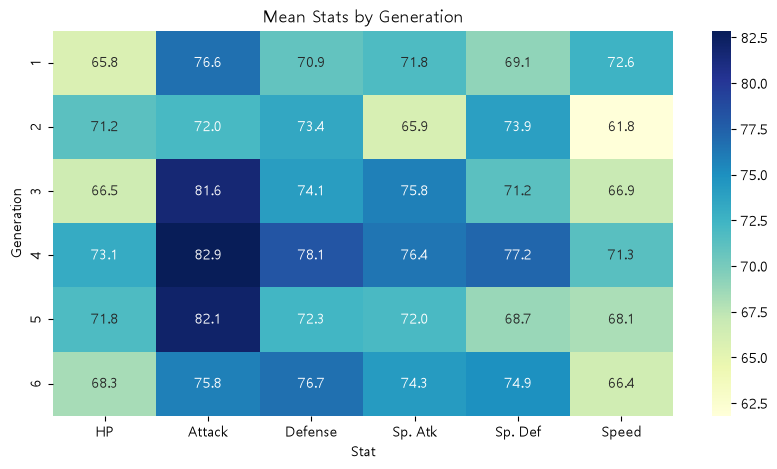

In [52]:
# heatmap 으로 판단
stat_columns = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']
generation_stats = df.groupby('Generation')[stat_columns].mean()
plt.figure(figsize=(10, 5))
sns.heatmap(
    generation_stats,
    annot=True, fmt='.1f', cmap='YlGnBu'
)
plt.title('Mean Stats by Generation')
plt.xlabel('Stat')
plt.ylabel('Generation')
plt.show()

눈에 가장 띄는 것은 4세대의 공격력 스텟이 많이 높고, 2세대 포켓몬의 속도가 많이 낮다는 것이다.

평균적으로 4세대의 능력치가 다른 세대에 비해 높은것으로 보이고, 2세대가 낮은 것으로 보인다. 1세대와 5세대의 포켓몬의 공격력이 해당 세대의 다른 능력치에 비해 높아보이지만 특별히 세대별로 높은 능력치가 존재하는 것 같아 보이지는 않는다. 

## 세대가 높아질수록 능력치 합 평균이 오르는가

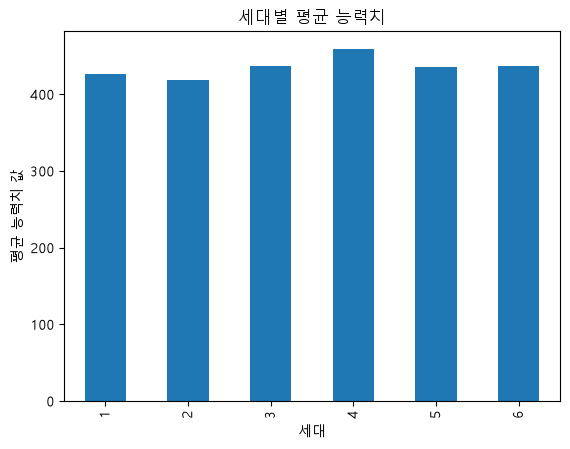

In [53]:
g = generation_df['Total'].plot(kind='bar')
plt.title('세대별 평균 능력치')
plt.xlabel('세대')
plt.ylabel('평균 능력치 값')
plt.show()

능력치별로 확인했을 때도 보였지만 4세대의 평균 능력치 총합이 가장 높고 2세대가 가장 낮은것으로 확인된다. 

특별히 세대가 높아진다고 스텟 총합이 계속 늘어나 inflation이 나오지는 않는다. 하지만 1~2 세대보다 3~6 세대의 총합이 조금 높은것은 사실이다.

## 세대마다 특별하게 많은 속성이 있는가

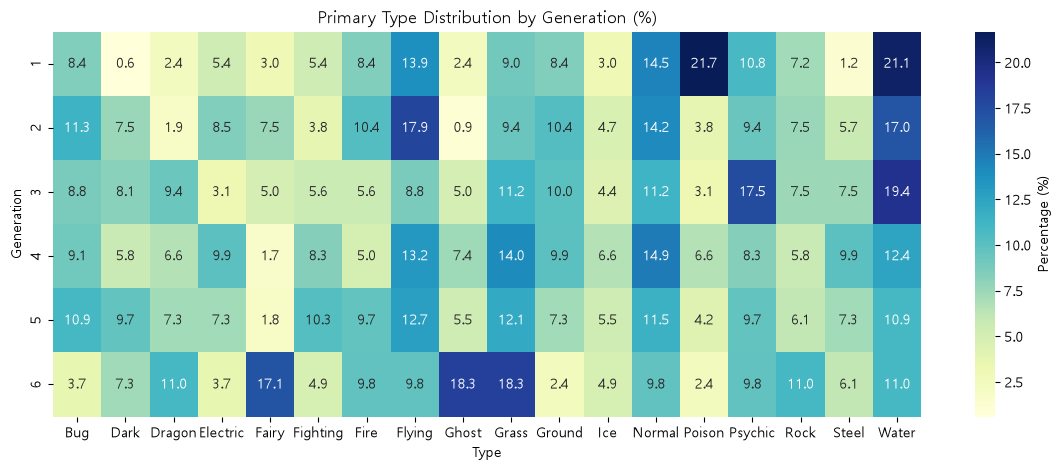

In [54]:
types_long = df.melt(
    id_vars='Generation',
    value_vars=['Type 1', 'Type 2'],
    value_name='Type'
).dropna(subset=['Type'])

type_counts = pd.crosstab(types_long['Generation'], types_long['Type'])
generation_sizes = df.groupby('Generation').size()

type_ratio = type_counts.div(generation_sizes, axis=0) * 100

plt.figure(figsize=(14, 5))
sns.heatmap(
    type_ratio,
    annot=True, fmt='.1f', cmap='YlGnBu',
    cbar_kws={'label': 'Percentage (%)'}
)
plt.title('Primary Type Distribution by Generation (%)')
plt.xlabel('Type')
plt.ylabel('Generation')
plt.show()

1 세대에 특히 물타입과 독타입이 많고 악 타입이 적은것이 확인된다. 독 타입은 1세대에는 굉장히 많지만 다른세대에는 많이 적은것으로 확인된다.

2세대 또한 고스트 타입이 좀 적지만 비행 타입과 물타입이 많은 것으로 보인다. 

3세대에는 특히 에스퍼 타입과 물타입이 많은 것이 확인된다.

4세대와 5세대는 대부분 고르게 잘 분포되어 있는것으로 보인다.

6세대에 생긴 페어리 타입은 6세대 포켓몬이 가장 많은 것이 확인 되고, 그 의외에도 6세대에 고스트 타입과 풀타입이 특히 많은것이 확인된다.

모든 세대에서 물타입, 노말타입, 비행타입 그리고 풀타입의 개체수가 다른 타입보다 많은 것으로 보인다.

## 세대가 높아질수록 포켓몬의 서브 타입도 많아 지는가

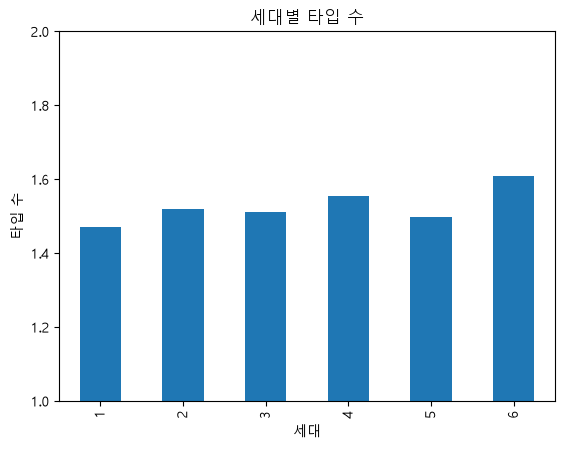

In [55]:
g = generation_df['Type_Count'].plot(kind='bar')
plt.title('세대별 타입 수')
plt.xlabel('세대')
plt.ylabel('타입 수')
plt.ylim((1, 2))
plt.show()

세대가 높아질수록 타입이 2개인 포켓몬의 수 또한 조금씩 높아지는 것으로 보인다. 

하지만 그 수가 매우 크게 변경되는 것은 아니므로 그렇게 크게 변화 되고 있다고 결론을 내리기에는 힘들다.

## 결론

1. 4세대 포켓몬의 공격력이 다른 세대보다 높은 것으로 보이나 특별히 세대 별로 뛰어난 능력치가 있는것으로 보이지는 않는다. 오히려 모든 세대의 포켓몬들의 공격력이 높은것이 특징이며 2세대와 6세대의 포켓몬의 공격력 평균이 다른 평균보다 낮다.

2. 평균적으로 세대가 높아질수록 능력치 총합또한 조금씩 높아지고 있으나, 그 수치가 게임에 악영향을 줄 정도로 크게 바뀌고 있지는 않다.

3. 1세대는 독타입, 2세대는 비행타입, 3세대는 에스퍼타입, 그리고 6세대는 페어리타입, 고스트타입, 풀타입의수가 많은것으로 확인됐다. 물타입은 1~3 세대에 공통적으로 많이 나왔다. 4세대와 5세대에는 특별히 많은 타입이 존재하지 않은것으로 확인된다. 페어리타입이 만들어진 6세대를 제외하면 변화가 보이는 것은 4세대이기 때문에, 무언가 회사 내부적으로 바뀐것이 있다고 예측이 된다.

4. 세대가 높아질수록 타입이 2개인 포켓몬이 늘어나고 있지만, 그 상향세가 그렇게 크지않고, 비슷하게 이어지고 있으므로, 특별히 늘어나고 있다고 판단하기는 어려운 것 같다.